In [1]:
import duckdb
import matplotlib.pyplot as plt

In [2]:
# verbinding met de data base
con = duckdb.connect("C:/Users/stijn/OneDrive/Documenten/GitHub/DataEngineering_M_S/dvdrental/dvdrental.duckdb", read_only=True)

In [4]:
# sql query 
df = con.execute("SELECT * FROM Fact_Omzet_Stad").df()

In [5]:
con.close()

In [ ]:
print(df)

     city_id                 city  total_omzet
0        442          Saint-Denis       211.55
1        101           Cape Coral       208.58
2        456  Santa Brbara dOeste       194.61
3         29            Apeldoorn       191.62
4        340            Molodetno       189.60
..       ...                  ...          ...
592      159                Enshi        49.88
593      516               Tafuna        47.85
594      520          Tallahassee        37.87
595      175               Fuzhou        32.90
596       97            Bydgoszcz        27.93

[597 rows x 3 columns]


### Top 10 steden met de meeste opbrengst

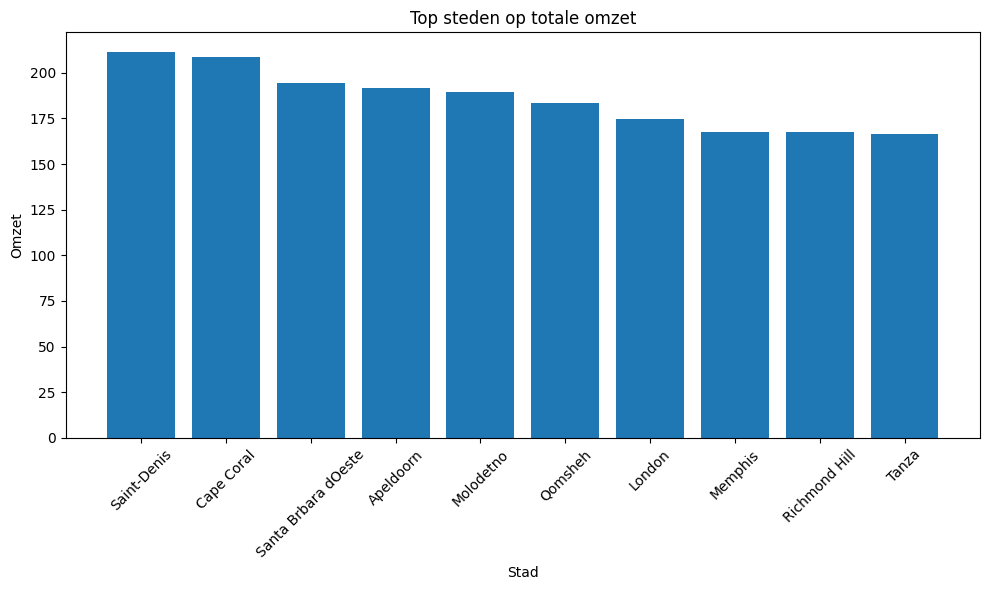

Saint-Denis: 0.35%
Cape Coral: 0.34%
Santa Brbara dOeste: 0.32%
Apeldoorn: 0.31%
Molodetno: 0.31%
Qomsheh: 0.30%
London: 0.28%
Memphis: 0.27%
Richmond Hill: 0.27%
Tanza: 0.27%


In [14]:
aantal = 10
top = df.sort_values('total_omzet', ascending=False).head(aantal)

total = df['total_omzet'].sum()
top['percentage'] = top['total_omzet'] / total * 100

plt.figure(figsize=(10, 6))
plt.bar(top['city'], top['total_omzet'])

plt.title('Top steden op totale omzet')
plt.xlabel('Stad')
plt.ylabel('Omzet')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for _, row in top.iterrows():
    print(f"{row['city']}: {row['percentage']:.2f}%")

### Top 10 steden met de minste opbrengst

ValueError: 'facecolor' or 'color' argument must be a valid color or sequence of colors.

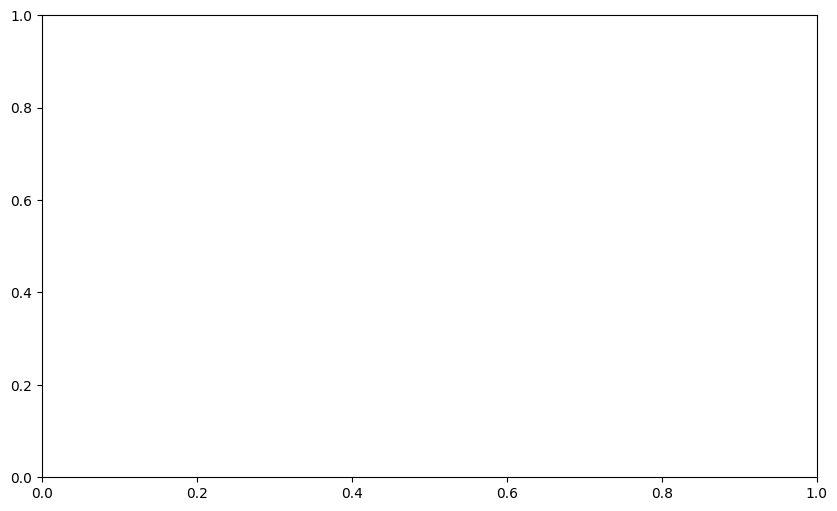

In [ ]:
aantal = 10
top = df.sort_values('total_omzet', ascending=True).head(aantal)

total = df['total_omzet'].sum()
top['percentage'] = top['total_omzet'] / total * 100

plt.figure(figsize=(10, 6))
plt.bar(top['city'], top['total_omzet'], facecolor = ['turbo'])
plt.title('Top steden op totale omzet')
plt.xlabel('Stad')
plt.ylabel('Omzet')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for _, row in top.iterrows():
    print(f"{row['city']}: {row['percentage']:.2f}%")

### De verdeling van de omzet per stad

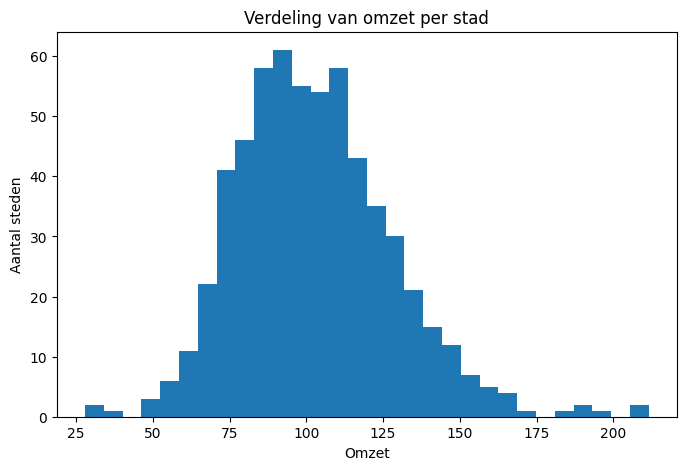

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['totale_omzet'], bins=30)
plt.title('Verdeling van omzet per stad')
plt.xlabel('Omzet')
plt.ylabel('Aantal steden')
plt.show()